# SCTEC - Projeto Avaliativo - Modulo 1

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import funcoes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree



df = pd.read_csv("dataset/E Commerce Dataset.xlsx - E Comm.csv")

## 1: Análise Exploratória de Dados (EDA)

### Descritiva e Estatística

In [23]:
print("#"*60+ "\n")
print(f"Tamanho do Dataset:")
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")
print("\n"+ "#"*60 )

############################################################

Tamanho do Dataset:
Total de linhas: 5630
Total de colunas: 20

############################################################


In [24]:
print("#"*60)
print("\n Visualizando os tipos dos dados\n")
print("#"*60 +"\n")
df.info()

############################################################

 Visualizando os tipos dos dados

############################################################

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 

In [25]:
print("#"*60)
print("\n Resumo Estatístico das Variáveis Numéricas\n")
print("#"*60 +"\n")
display(df.describe())

############################################################

 Resumo Estatístico das Variáveis Numéricas

############################################################



,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [26]:
print("#"*60)
print("\n Visualizando a estrutura inicial dos dados\n")
print("#"*60 +"\n")
display(df.head(10))

############################################################

 Visualizando a estrutura inicial dos dados

############################################################



,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,121
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,123
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,127
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,123


### Visual

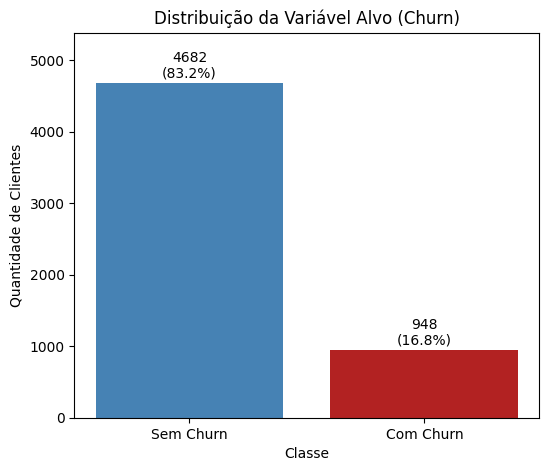

In [27]:
### A distribuição de Churn para visualizar           ###
### de como está o target, se está balanceado ou não. ###

# Contagem da variável alvo
churn = df['Churn'].value_counts().sort_index()

# Percentual da variável alvo
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

# Gráfico
fig, ax = plt.subplots(figsize=(6,5))

bars = ax.bar(
    ['Sem Churn', 'Com Churn'],
    churn.values,
    color=['steelblue', 'firebrick']
)

# Adiciona quantidade e porcentagem acima de cada barra
for bar, qtd, pct in zip(bars, churn.values, churn_pct.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{qtd}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Clientes')
plt.ylim(0, churn.max() * 1.15)
plt.show()

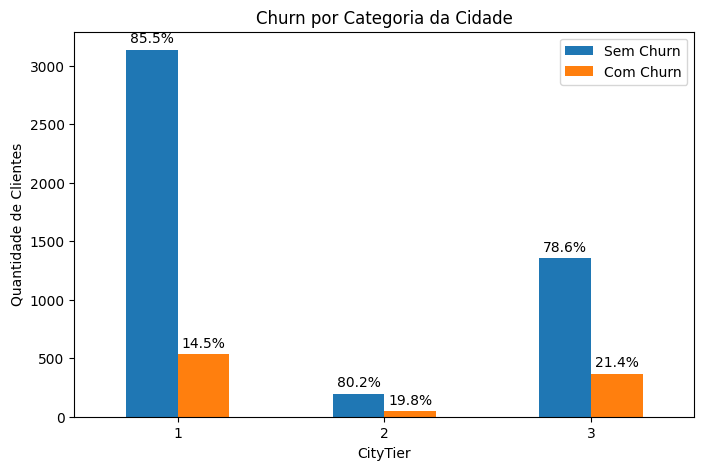

In [28]:
###  Optei usar a coluna Churn/CityTier para fazer o histograma  ###

# Contagem
churn_city = pd.crosstab(df['CityTier'], df['Churn'])

# Percentual por CityTier
churn_city_pct = pd.crosstab(
    df['CityTier'],
    df['Churn'],
    normalize='index'
) * 100

# Gráfico
ax = churn_city.plot(kind='bar', figsize=(8,5))

plt.title('Churn por Categoria da Cidade')
plt.xlabel('CityTier')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)
plt.legend(['Sem Churn', 'Com Churn'])

# Adiciona as porcentagens acima das barras
for i, container in enumerate(ax.containers):
    labels = [f'{pct:.1f}%' for pct in churn_city_pct.iloc[:, i]]
    ax.bar_label(
        container,
        labels=labels,
        label_type='edge',   # coloca em cima da barra
        padding=3,           # distância da barra
        fontsize=10
    )

plt.show()

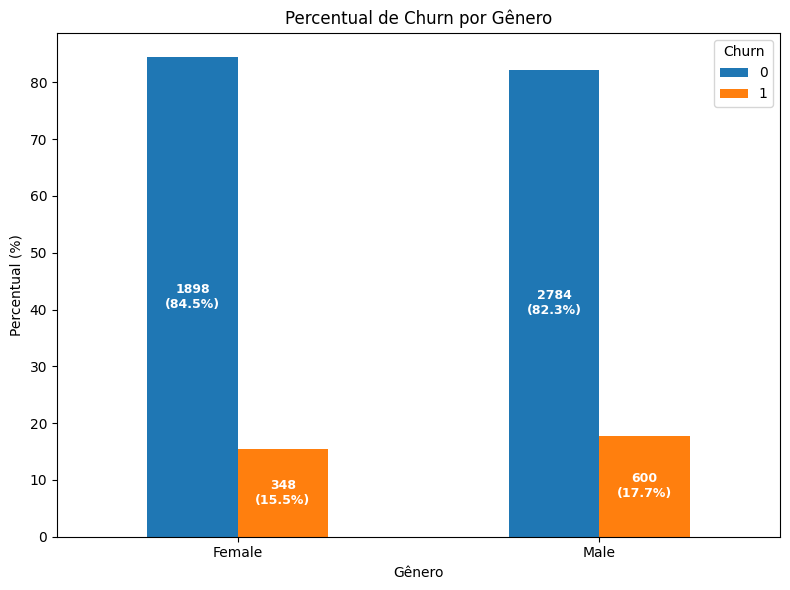

In [29]:
### Fiz esse outro para verificar se tem discrepancia entre o genero e o target Churn, ###
### se tem algum genero que tem mais tendencia a desistir da compra do que outro.      ###

# Percentuais
churn_gender_pct = pd.crosstab(
    df['Gender'],
    df['Churn'],
    normalize='index'
) * 100

# Quantidades
churn_gender_count = pd.crosstab(
    df['Gender'],
    df['Churn']
)

# Gráfico
ax = churn_gender_pct.plot(kind='bar', figsize=(8,6))

plt.title('Percentual de Churn por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Percentual (%)')
plt.legend(title='Churn')
plt.xticks(rotation=0)

# Adiciona quantidade e percentual em cada barra
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        qtd = churn_gender_count.iloc[j, i]
        pct = churn_gender_pct.iloc[j, i]
        labels.append(f'{qtd}\n({pct:.1f}%)')

    ax.bar_label(
    container,
    labels=labels,
    label_type='center',   # coloca o texto no centro da barra
    fontsize=9,
    color='white',
    weight='bold'
    )

plt.tight_layout()
plt.show()

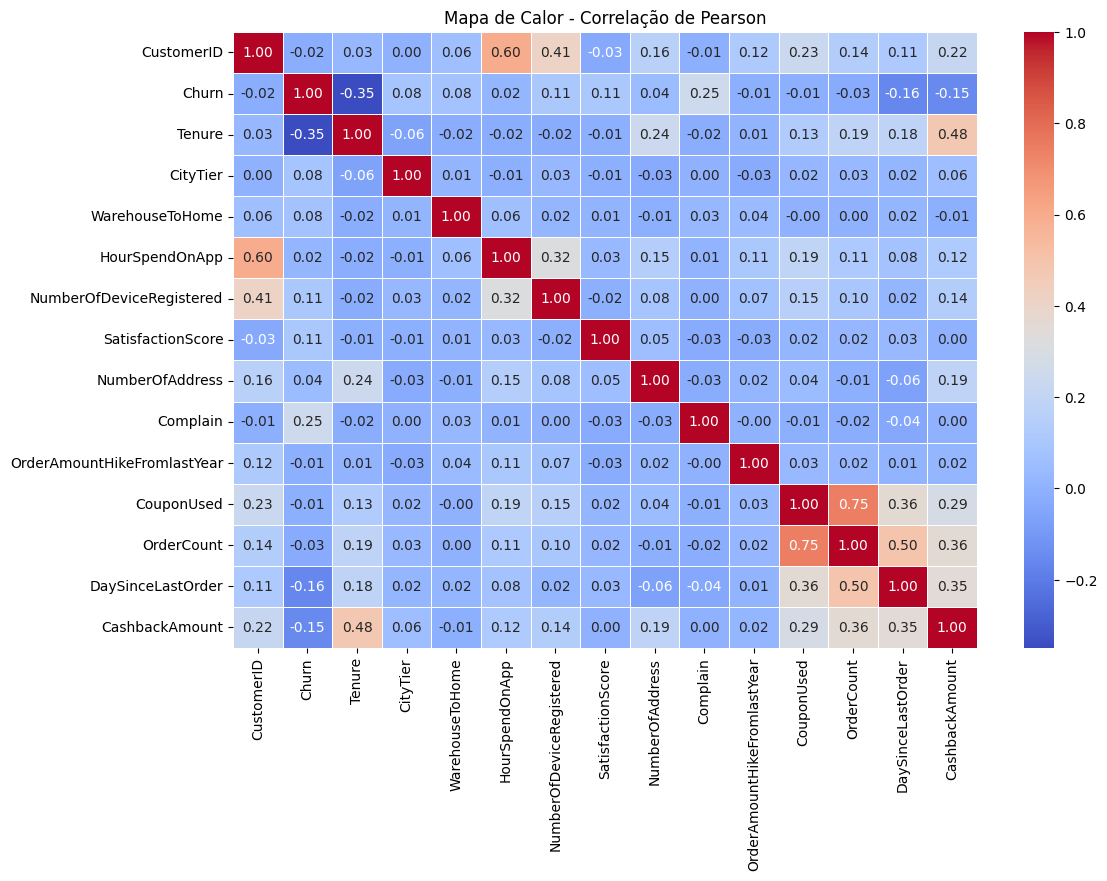

In [30]:
### Mapa de calor para visualizar a correlação ###
### entre as variáveis numéricas do dataset.   ###

# Seleciona apenas colunas numéricas
df_numeric = df.select_dtypes(include='number')

# Calcula a matriz de correlação de Pearson
corr = df_numeric.corr(method='pearson')

# Gráfico de mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,      # Mostra os valores da correlação
    cmap='coolwarm', # Azul = negativo | Vermelho = positivo
    fmt='.2f',       # Duas casas decimais
    linewidths=0.5
)

plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()

### Tomada de Decisão

A análise exploratória revelou que o conjunto de dados apresenta um desbalanceamento na variável alvo (Churn), com predominância de clientes que permaneceram na empresa em relação aos que cancelaram seus serviços. Também foram identificados valores ausentes em algumas variáveis, como Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount e DaySinceLastOrder, os quais serão tratados utilizando a mediana — ou a mediana por grupo (CityTier) quando a variável possuí relação com essa característica —, preservando melhor a distribuição dos dados. A matriz de correlação de Pearson mostrou que não existem correlações lineares muito fortes entre a maioria das variáveis e o Churn, destacando-se apenas uma correlação negativa moderada entre Tenure e Churn (-0,35), indicando que clientes com maior tempo de relacionamento tendem a apresentar menor probabilidade de evasão. Também foram observadas correlações elevadas entre CouponUsed e OrderCount (0,75), sugerindo uma relação direta entre a frequência de compras e o uso de cupons. Com base nesses resultados, a estratégia de preparação consistirá na remoção da coluna CustomerID, por se tratar apenas de um identificador. Para as próximas etapas, serão mantidas as variáveis numéricas, realizada a codificação das variáveis categóricas para algoritmos de aprendizado de máquina, e aplicadas técnicas de balanceamento de classes, avaliando o modelo por meio de métricas apropriadas para dados desbalanceados.

## 2: Tratamento e Limpeza (Data Prep)

In [31]:
# Excluindo a coluna 'CustomerID' do DataFrame, pois não é relevante para a análise
df = df.drop(columns=['CustomerID'])

# Criando uma copia do DataFrame original para limpeza e manipulação
df_clean = df.copy()

# Preenche os valores ausentes de Tenure com a MEDIANA
df_clean['Tenure'] = df_clean['Tenure'].fillna(df_clean['Tenure'].median())

# Preenche os valores ausentes de WarehouseToHome com a MEDIANA de cada TierCity
df_clean['WarehouseToHome'] = (
    df_clean.groupby('CityTier')['WarehouseToHome']
      .transform(lambda x: x.fillna(x.median()))
)

# Preenche os valores ausentes de HourSpendOnApp com a MEDIANA de cada TierCity
df_clean['HourSpendOnApp'] = (
    df_clean.groupby('CityTier')['HourSpendOnApp']
      .transform(lambda x: x.fillna(x.median()))
)

# Preenche os valores ausentes de Percentual de aumento do valor dos pedidos
df_clean['OrderAmountHikeFromlastYear'] = (
    df_clean['OrderAmountHikeFromlastYear']
    .fillna(df_clean['OrderAmountHikeFromlastYear'].median())
)

# Preenche os valores ausentes de Quantidade de cupons utilizados
df_clean['CouponUsed'] = (
    df_clean['CouponUsed']
    .fillna(df_clean['CouponUsed'].median())
)

# Preenche os valores ausentes de Número de pedidos
df_clean['OrderCount'] = (
    df_clean['OrderCount']
    .fillna(df_clean['OrderCount'].median())
)

# Preenche os valores ausentes de Dias desde o último pedido
df_clean['DaySinceLastOrder'] = (
    df_clean['DaySinceLastOrder']
    .fillna(df_clean['DaySinceLastOrder'].median())
)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

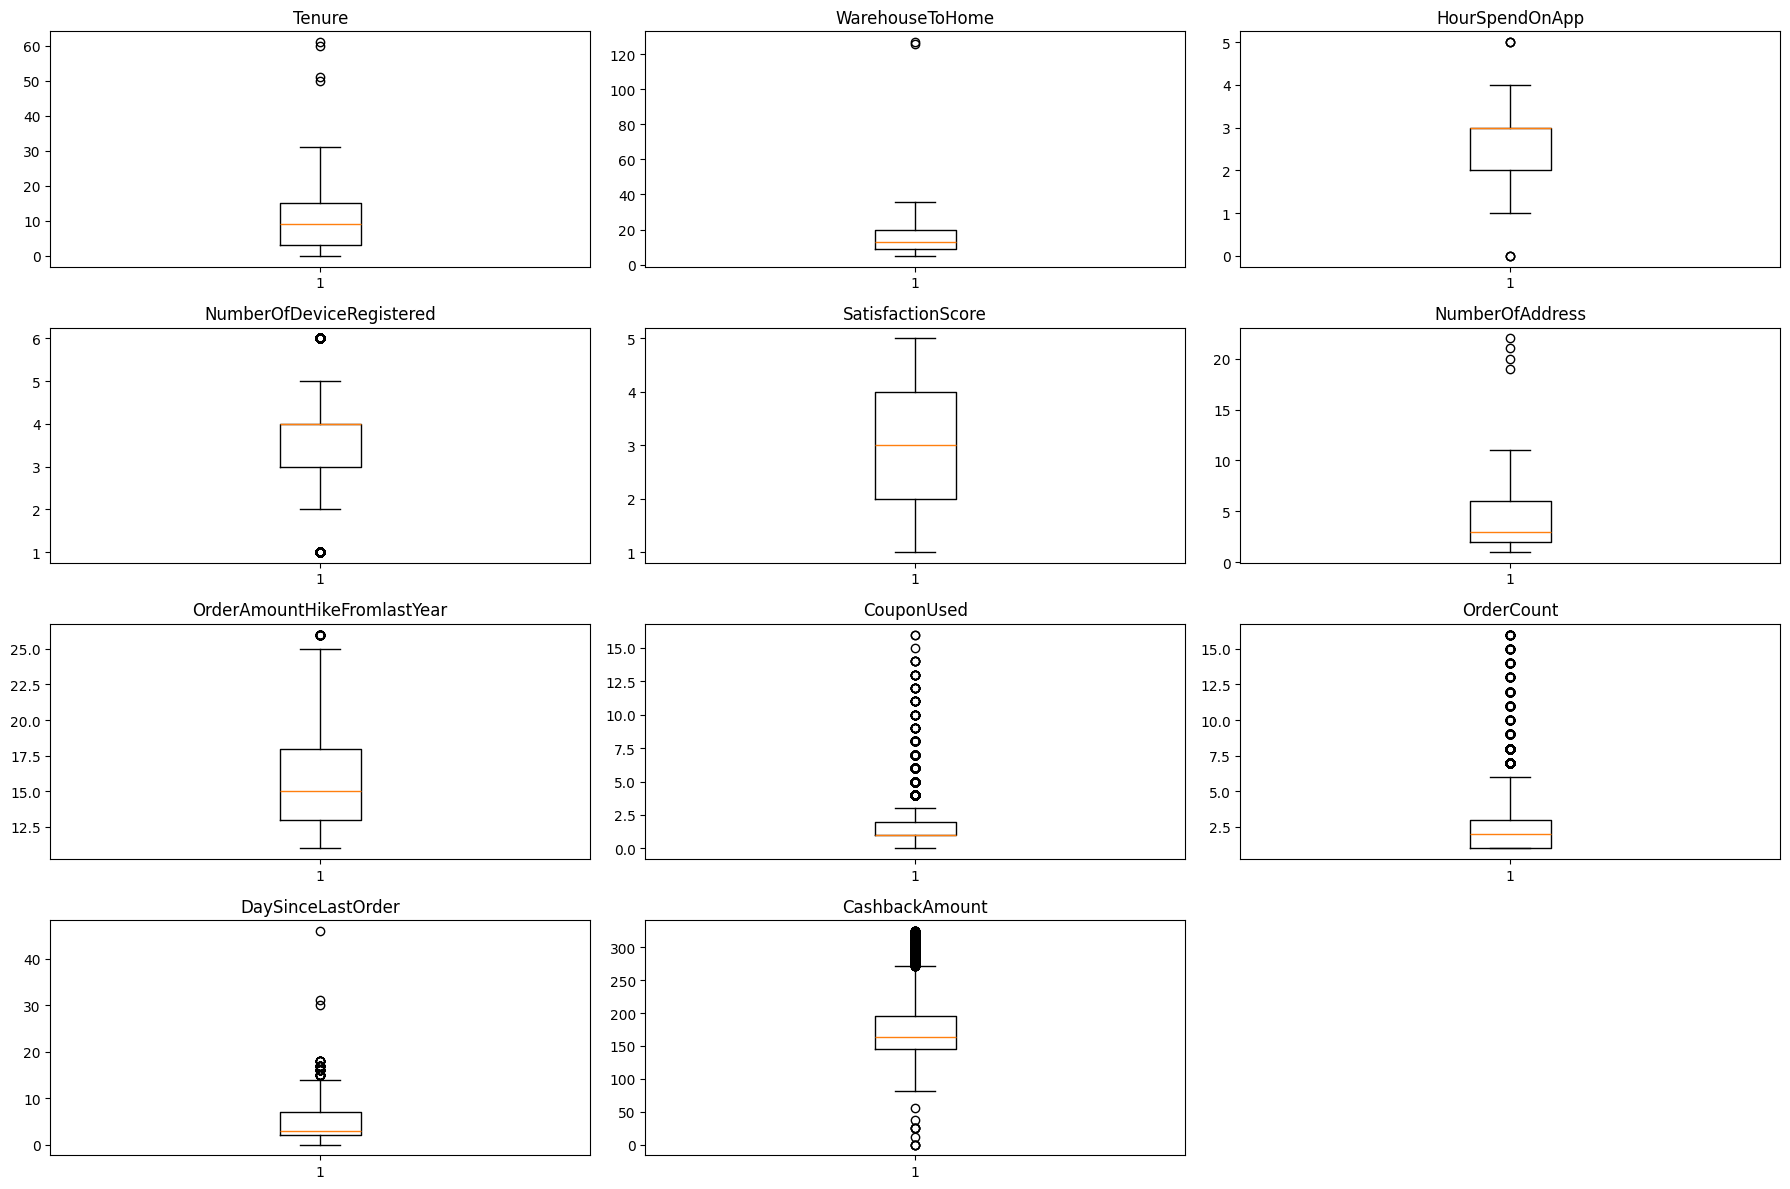

In [32]:
# Excluindo as colunas Churn, CityTier e Complain para análise de boxplot
df_numeric2 = df_clean.select_dtypes(include='number').drop(columns=['Churn', 'Complain', 'CityTier'])  

plt.figure(figsize=(18, 12))

for i, coluna in enumerate(df_numeric2.columns):
    plt.subplot(4, 3, i + 1)   # agora cabem até 16 gráficos
    plt.boxplot(df_numeric2[coluna], vert=True)
    plt.title(coluna)

plt.tight_layout()
plt.show()

### Fudamento para tratamento dos Outliers

Analisando e identificando os outliers, optei por mantê-los. Acredito que apresentam comportamentos legítimos de negócio.

## 3: Feature Engineering (Coluna Calculada)

In [33]:
# Criando a coluna CashBackByOrder, que representa o valor do cashback por pedido, evitando divisão por zero.
df_clean['CashBackByOrder'] = np.where(df_clean['OrderCount'] > 0, df_clean['CashbackAmount'] / df_clean['OrderCount'], 0)

# verificando se a coluna foi criada corretamente e se não há valores nulos
df_clean['CashBackByOrder'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5630 entries, 0 to 5629
Series name: CashBackByOrder
Non-Null Count  Dtype  
--------------  -----  
5630 non-null   float64
dtypes: float64(1)
memory usage: 44.1 KB


## 4: Separação, Balanceamento e Escalonamento Seguro

### Encoding

In [34]:
# Instanciar o encoder (drop='first' evita colunas redundantes)
ohe = OneHotEncoder(drop='first', sparse_output=False)
col_cat = ['Gender']
col_trans = ohe.fit_transform(df_clean[col_cat])

df_cat_encoded = pd.DataFrame(
    col_trans, 
    columns=ohe.get_feature_names_out(col_cat),
    index=df_clean.index  # Mantém os mesmos índices do DataFrame original para não desalentar as linhas
)

# Dropar as colunas de texto originais e juntar com as novas colunas codificadas
df_encoded = df_clean.drop(columns=col_cat)
df_encoded = pd.concat([df_encoded, df_cat_encoded], axis=1)

df_encoded = pd.get_dummies(df_encoded, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'MaritalStatus'])

display(df_encoded.head(7))
display(df_encoded.info())
print(f"Colunas saltaram para {df_encoded.shape[1]} após criar os 'interruptores' 0 e 1.")


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_CC,PreferredPaymentMode_COD,PreferredPaymentMode_Cash on Delivery,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,Laptop & Accessory,2,9,1,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,Mobile,3,7,1,...,False,False,False,False,False,False,True,False,False,True
2,1,9.0,1,30.0,2.0,4,Mobile,3,6,1,...,False,False,False,False,True,False,False,False,False,True
3,1,0.0,3,15.0,2.0,4,Laptop & Accessory,5,8,0,...,False,False,False,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,Mobile,5,3,0,...,True,False,False,False,False,False,False,False,False,True
5,1,0.0,1,22.0,3.0,5,Mobile Phone,5,2,1,...,False,False,False,False,True,False,False,False,False,True
6,1,9.0,3,11.0,2.0,3,Laptop & Accessory,2,4,0,...,False,False,True,False,False,False,False,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  5630 non-null   int64  
 1   Tenure                                 5630 non-null   float64
 2   CityTier                               5630 non-null   int64  
 3   WarehouseToHome                        5630 non-null   float64
 4   HourSpendOnApp                         5630 non-null   float64
 5   NumberOfDeviceRegistered               5630 non-null   int64  
 6   PreferedOrderCat                       5630 non-null   object 
 7   SatisfactionScore                      5630 non-null   int64  
 8   NumberOfAddress                        5630 non-null   int64  
 9   Complain                               5630 non-null   int64  
 10  OrderAmountHikeFromlastYear            5630 non-null   float64
 11  Coup

None

Colunas saltaram para 30 após criar os 'interruptores' 0 e 1.


### Split de Dados

In [35]:
# Vamos prever o Churn. O 'y' é o alvo, o 'X' é o resto.
X = df_encoded.drop(columns=['Churn', 'PreferedOrderCat'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Como separamos o 'y', podemos usá-lo aqui para estratificar!
)
print(f"Dados de Treino: {X_train.shape[0]} para a IA treinar.")
print(f"Dados de Teste: {X_test.shape[0]} para testar.")

Dados de Treino: 4504 para a IA treinar.
Dados de Teste: 1126 para testar.


### Escalonamento Seguro

In [36]:
# Padronizando os dados.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Balanceamento de Classes

In [37]:
# Instanciando o SMOTE
smote = SMOTE(random_state=42)
X_train_scaled_smoted, y_train_scaled_smoted = smote.fit_resample(X_train_scaled, y_train)

print("Antes do SMOTE (Treino):")
print(y_train.value_counts())

print("\nDepois do SMOTE (Treino):")
print(pd.Series(y_train_scaled_smoted).value_counts())

Antes do SMOTE (Treino):
Churn
0    3746
1     758
Name: count, dtype: int64

Depois do SMOTE (Treino):
Churn
0    3746
1    3746
Name: count, dtype: int64


## 5: Modelagem e Validação (O Desafio do Overfitting)

### KNN - K-Nearest Neighbors

In [38]:
#Trinando o KNN com os dados SCALED e com os dados SCALED+SMOTED

# 
valores = [3, 5, 7, 9, 11]
lista_KNN_scaled = funcoes.treino_KNN(X_train_scaled, y_train, X_test_scaled, y_test, valores)

lista_KNN_scaled_smoted = funcoes.treino_KNN(X_train_scaled_smoted, y_train_scaled_smoted, X_test_scaled, y_test, valores)



Treinando o algoritmo KNN (Mapeando distâncias 3)

Relatório de Classificação (Churn): 0 / 1:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       936
           1       0.66      0.56      0.61       190

    accuracy                           0.88      1126
   macro avg       0.79      0.75      0.77      1126
weighted avg       0.87      0.88      0.87      1126


Treinando o algoritmo KNN (Mapeando distâncias 5)

Relatório de Classificação (Churn): 0 / 1:
              precision    recall  f1-score   support

           0       0.91      0.97      0.93       936
           1       0.75      0.51      0.60       190

    accuracy                           0.89      1126
   macro avg       0.83      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126


Treinando o algoritmo KNN (Mapeando distâncias 7)

Relatório de Classificação (Churn): 0 / 1:
              precision    recall  f1-score   support

      

In [39]:
tipos = ['SCALED', 'SMOTED']
funcoes.comparar_resultados_KNN(lista_KNN_scaled, lista_KNN_scaled_smoted)

K = 3   ----------------------SCALED---------------------- ----------------------SMOTED----------------------
              precision    recall  f1-score   support                      precision    recall  f1-score   support
                                                             
           0       0.91      0.94      0.93       936                   0       0.97      0.88      0.92       936
           1       0.66      0.56      0.61       190                   1       0.59      0.85      0.70       190
                                                             
    accuracy                           0.88      1126            accuracy                           0.87      1126
   macro avg       0.79      0.75      0.77      1126           macro avg       0.78      0.87      0.81      1126
weighted avg       0.87      0.88      0.87      1126        weighted avg       0.90      0.87      0.88      1126
----------------------------------------------------------------------------

### Decision Tree

In [40]:
# No meu teste o depth 11 apresentou melhor desempenho por isso adicionei ele na lista de profundidades para testar o DecisionTreeClassifier.
depth = [3, 5, 7, 11, None]
lista_tree = funcoes.treino_DecisionTree(X_train, y_train, X_test, y_test, depth)


Treinando o algoritmo Decision Tree (Profundidade 3)

Relatório de Churn: 0 / 1:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       936
           1       0.70      0.51      0.59       190

    accuracy                           0.88      1126
   macro avg       0.80      0.73      0.76      1126
weighted avg       0.87      0.88      0.87      1126


Treinando o algoritmo Decision Tree (Profundidade 5)

Relatório de Churn: 0 / 1:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       936
           1       0.75      0.50      0.60       190

    accuracy                           0.89      1126
   macro avg       0.83      0.73      0.77      1126
weighted avg       0.88      0.89      0.88      1126


Treinando o algoritmo Decision Tree (Profundidade 7)

Relatório de Churn: 0 / 1:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94  

In [41]:
funcoes.comparar_resultados_KNN_DECISIONTREE(lista_KNN_scaled, lista_tree)

K = 3   --------------------KNN_SCALED-------------------- ------------------DECISION_TREE------------------- Depth = 3  
              precision    recall  f1-score   support                      precision    recall  f1-score   support
                                                             
           0       0.91      0.94      0.93       936                   0       0.90      0.96      0.93       936
           1       0.66      0.56      0.61       190                   1       0.70      0.51      0.59       190
                                                             
    accuracy                           0.88      1126            accuracy                           0.88      1126
   macro avg       0.79      0.75      0.77      1126           macro avg       0.80      0.73      0.76      1126
weighted avg       0.87      0.88      0.87      1126        weighted avg       0.87      0.88      0.87      1126
----------------------------------------------------------------

TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
# importances = lista_tree[4]['model'].feature_importances_
# feature_names = X.columns

# # Criar um DataFrame para melhor visualização
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# print("\nImportância das Features no Modelo:")
# display(feature_importance_df)

# # Visualizar a importância das features
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Importância das Features na Árvore de Decisão', fontweight='bold')
# plt.xlabel('Importância (Gini/Entropia)')
# plt.ylabel('Feature')
# plt.show()